# First SVC Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

Optimal Parameters: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy of the current model: 80.0


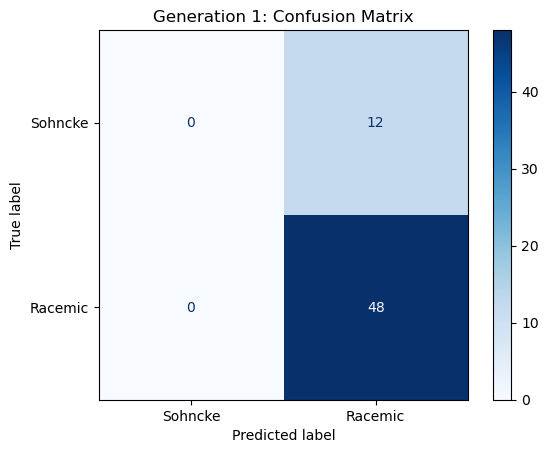

In [3]:
list = r'filtered and normalised all descriptor data.csv' # Pulling the data

df = pd.read_csv(list) # Creating the dataframe

# df.dtypes # Checks the type of data each column has

df_cleaned = df.drop(columns=['Point group', 'Refcode']) # Cleaning the database and getting rid of any rows that aren't 'float64'

feature_df = df_cleaned.drop(columns=['Target']) # Creating a new dataframe with just the sohncke/racemic answers

X = np.asarray(feature_df) # Putting all the descriptor information in an array
y = np.asarray(df_cleaned['Target']) # Putting all the target information in an array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20) # Generating the training and testing data with a 80/20 split

# Trying to obtain the most optimal parameters for the model
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

optimal_params = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0
)

optimal_params.fit(X_train, y_train)
print(f'Optimal Parameters: {optimal_params.best_params_}') # Printing out the optimal conditions

classifier = optimal_params.best_estimator_ # Storing the optimal conditions
classifier.fit(X_train, y_train) # Using the optimial conditions for the model

y_predict = classifier.predict(X_test) # Predicting sohncke/racemic with the new model

print("Accuracy of the current model:",metrics.accuracy_score(y_test, y_predict)*100) # Printing out the accuracy

# Outputting the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    classifier, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Generation 1: Confusion Matrix');

---
# Obtaining 90% Accuracy with a SVC Model

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import joblib

Accuracy of the current model: 88.33%
Accuracy of the current model: 88.33%
Accuracy of the current model: 93.33%
Optimal Parameters: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}


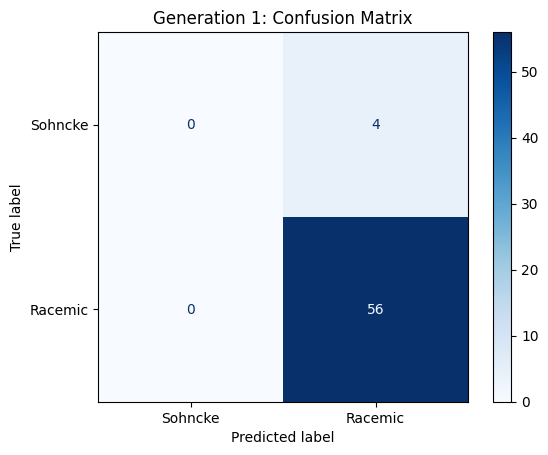

Model saved to best_svc_model_gen_1.pkl


In [29]:
# Load the data
file_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(file_path)

# Clean the data
df_cleaned = df.drop(columns=['Point group', 'Refcode'])

# Prepare feature and target arrays
feature_df = df_cleaned.drop(columns=['Target'])
X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Loop until the accuracy is above 90%
accuracy = 0
while accuracy < 90:
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    # Define the parameter grid
    param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

    # Initialize GridSearchCV
    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )

    # Fit the model
    optimal_params.fit(X_train, y_train)
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)

    # Predict on the test set
    y_predict = classifier.predict(X_test)

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    print(f"Accuracy of the current model: {accuracy:.2f}%")
    
    if accuracy >= 90:
        print(f"Optimal Parameters: {optimal_params.best_params_}")
        
        # Output the confusion matrix
        ConfusionMatrixDisplay.from_estimator(
            classifier, 
            X_test, 
            y_test, 
            display_labels=["Sohncke", "Racemic"],
            cmap=plt.cm.Blues,
            values_format='d'
        )
        plt.title('Generation 1: Confusion Matrix')
        plt.show()
        
        # Save the model
        joblib_file = "best_svc_model_gen_1.pkl"
        joblib.dump(classifier, joblib_file)
        print(f"Model saved to {joblib_file}")


---

# Average of 100 runs

---

Run 1 completed with accuracy: 93.33333333333333


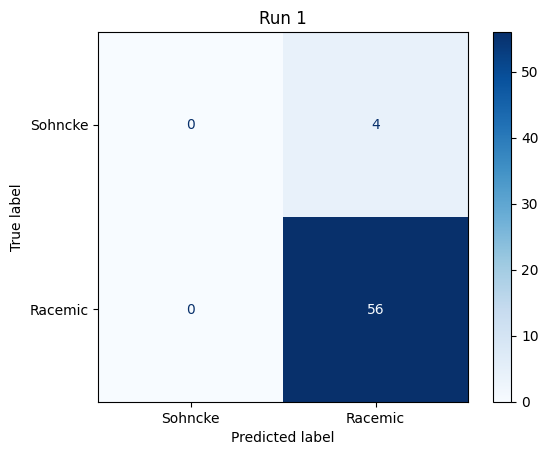

Run 2 completed with accuracy: 81.66666666666667


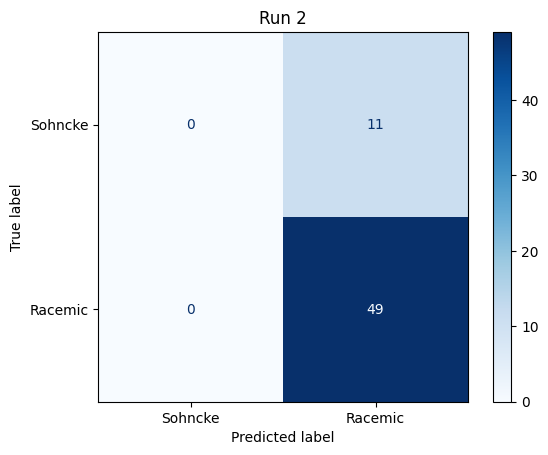

Run 3 completed with accuracy: 85.0


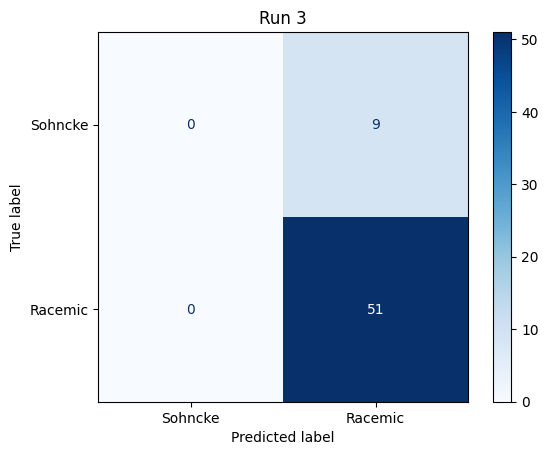

Run 4 completed with accuracy: 88.33333333333333


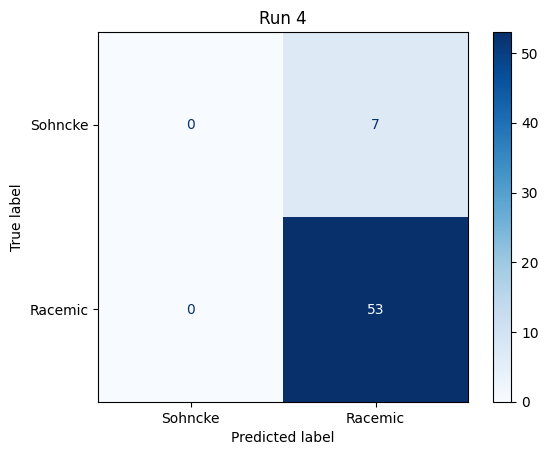

Run 5 completed with accuracy: 81.66666666666667


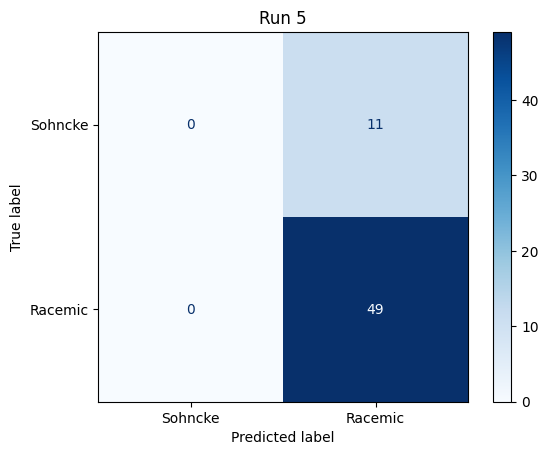

Run 6 completed with accuracy: 88.33333333333333


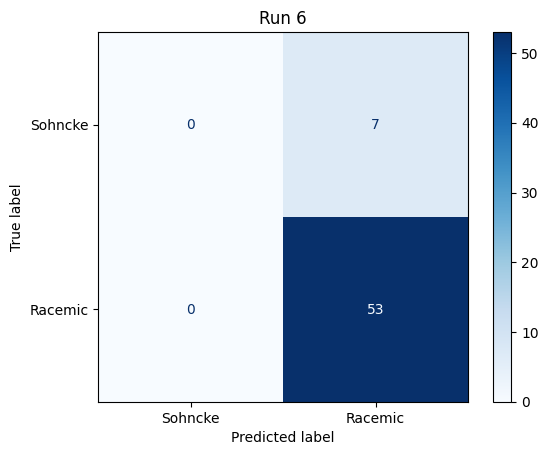

Run 7 completed with accuracy: 88.33333333333333


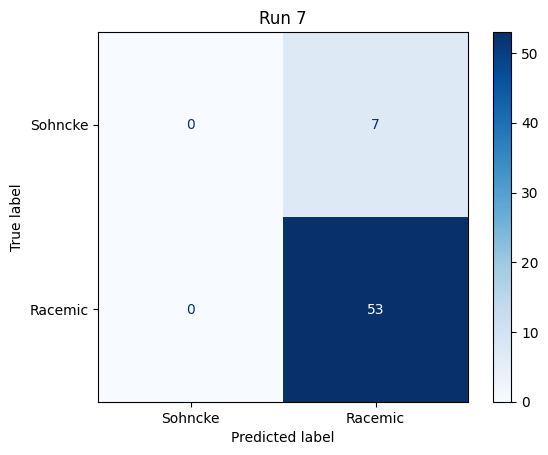

Run 8 completed with accuracy: 85.0


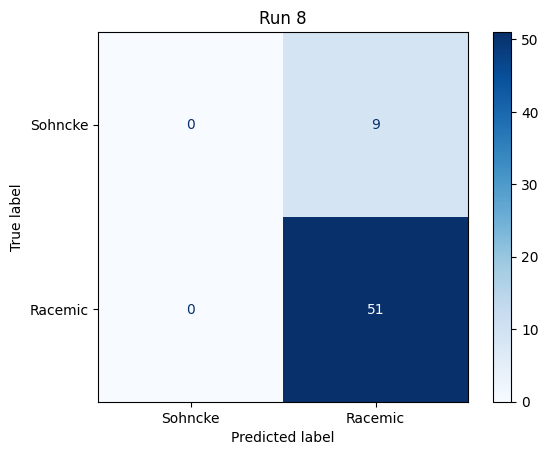

Run 9 completed with accuracy: 81.66666666666667


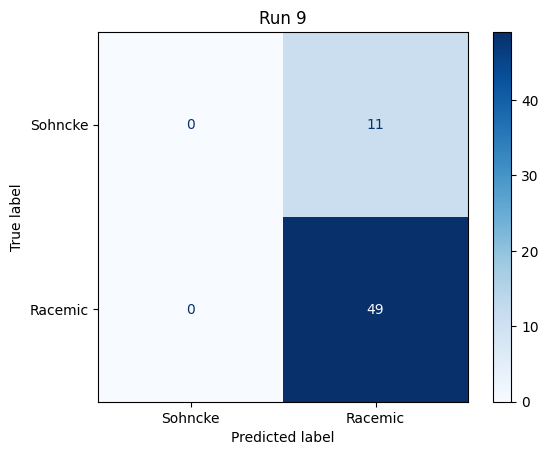

Run 10 completed with accuracy: 91.66666666666666


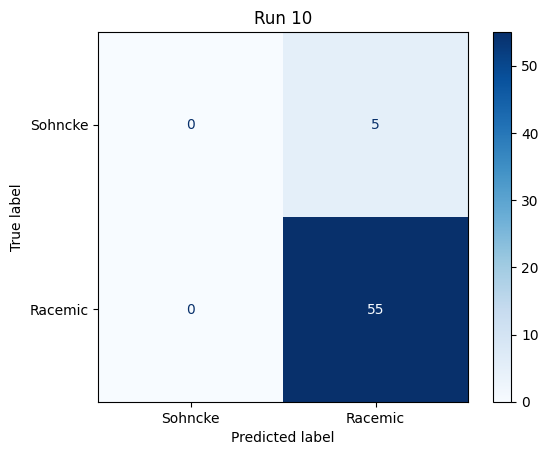

Run 11 completed with accuracy: 90.0


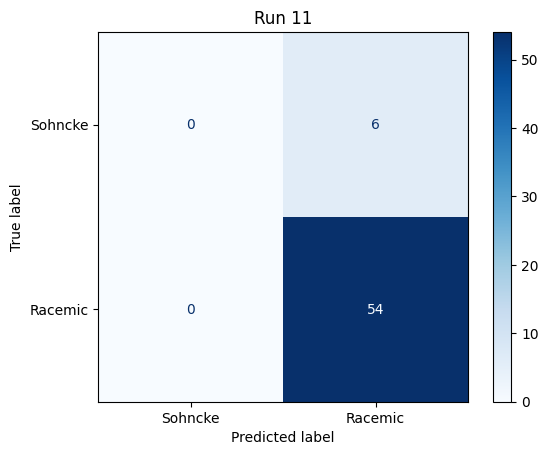

Run 12 completed with accuracy: 86.66666666666667


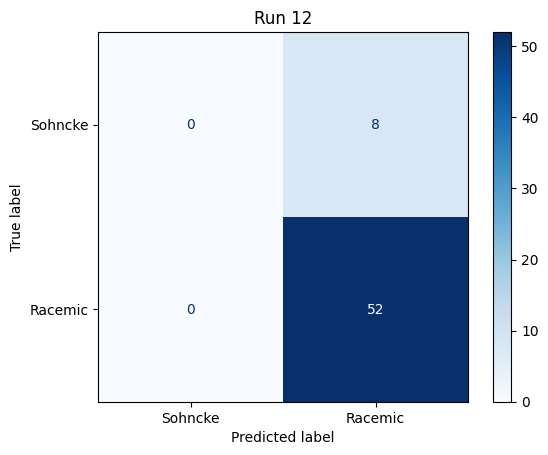

Run 13 completed with accuracy: 90.0


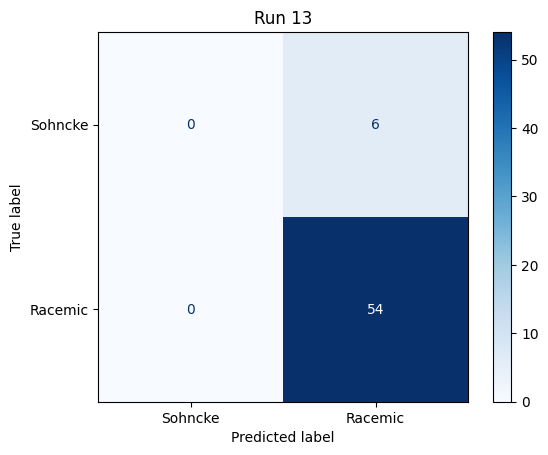

Run 14 completed with accuracy: 83.33333333333334


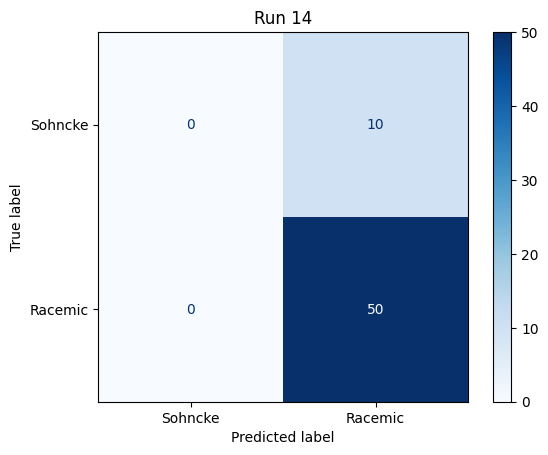

Run 15 completed with accuracy: 78.33333333333333


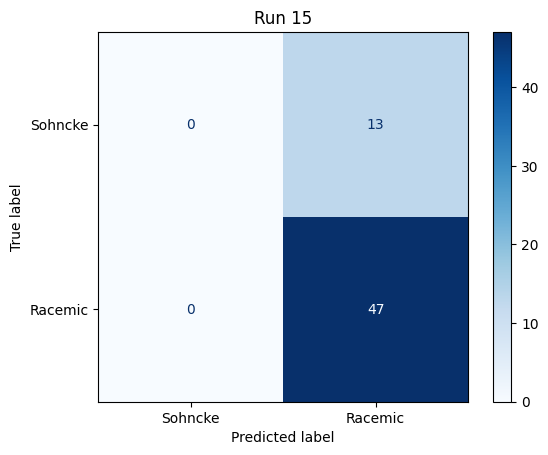

Run 16 completed with accuracy: 86.66666666666667


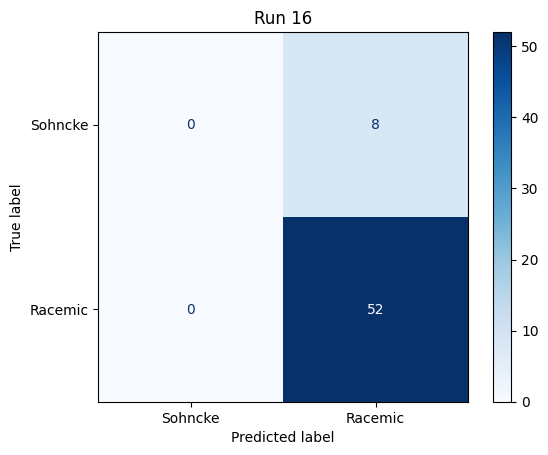

Run 17 completed with accuracy: 85.0


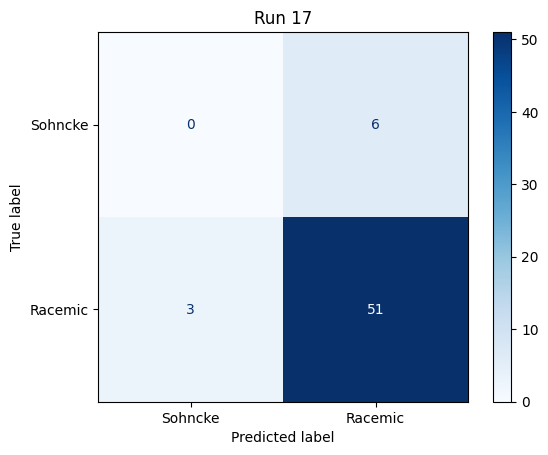

Run 18 completed with accuracy: 81.66666666666667


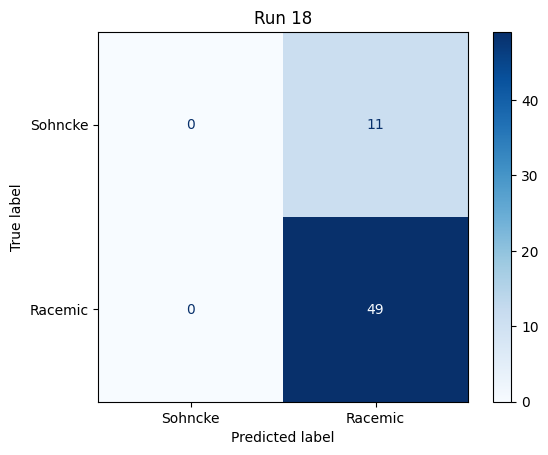

Run 19 completed with accuracy: 83.33333333333334


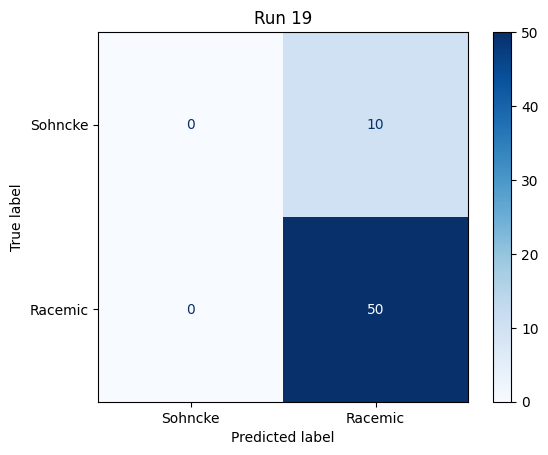

Run 20 completed with accuracy: 90.0


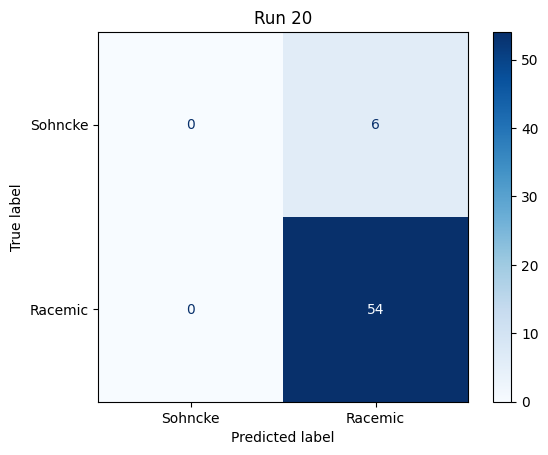

Run 21 completed with accuracy: 81.66666666666667


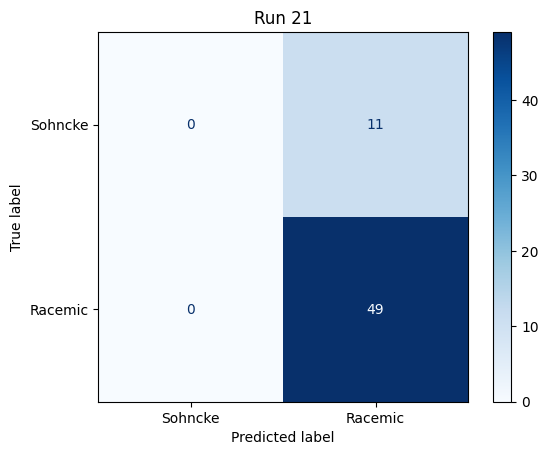

Run 22 completed with accuracy: 86.66666666666667


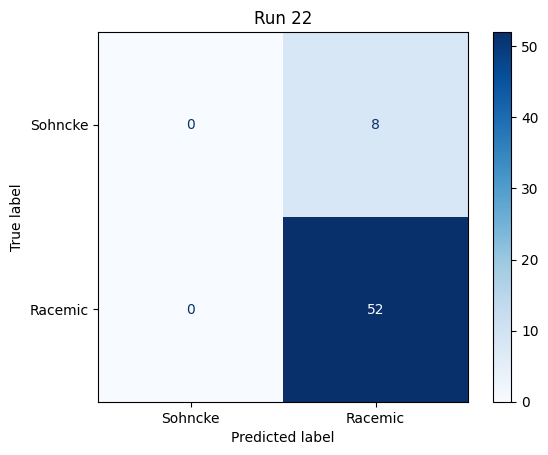

Run 23 completed with accuracy: 88.33333333333333


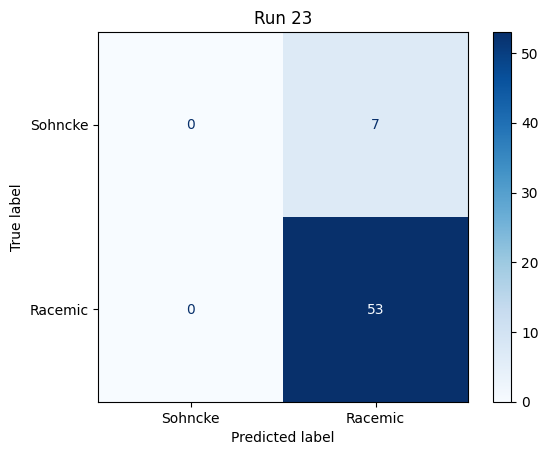

Run 24 completed with accuracy: 88.33333333333333


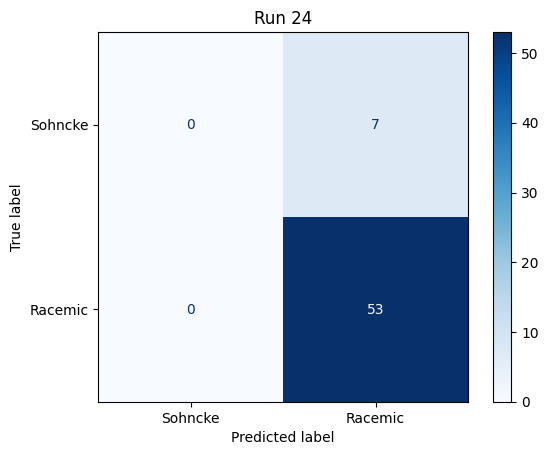

Run 25 completed with accuracy: 90.0


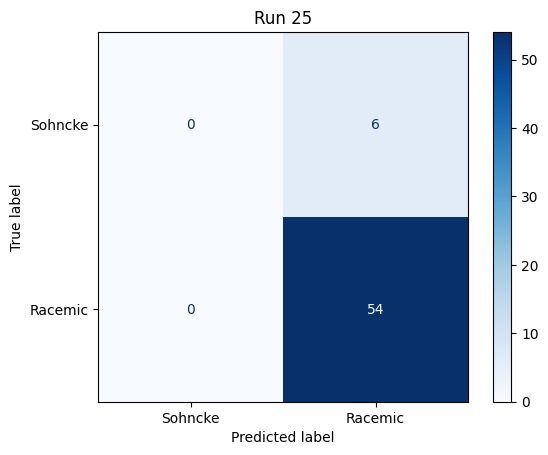

Run 26 completed with accuracy: 88.33333333333333


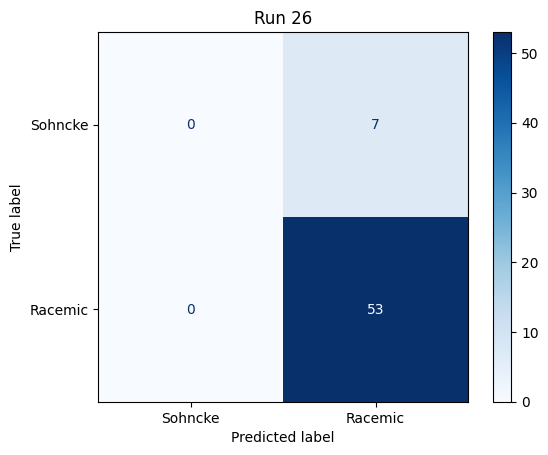

Run 27 completed with accuracy: 83.33333333333334


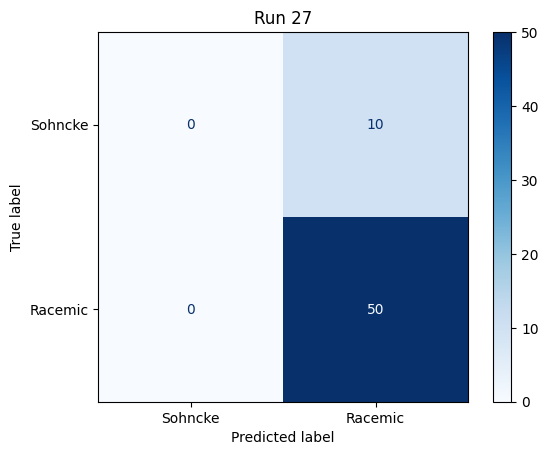

Run 28 completed with accuracy: 81.66666666666667


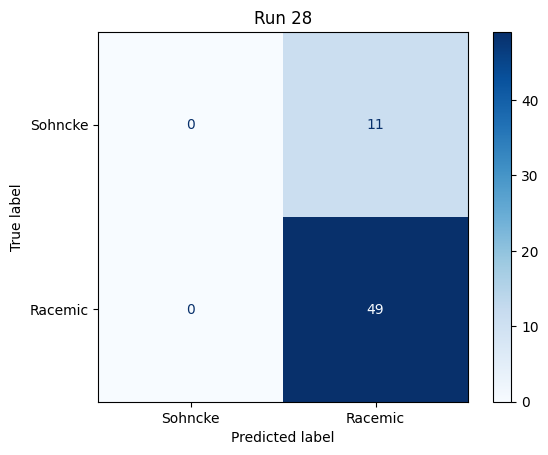

Run 29 completed with accuracy: 88.33333333333333


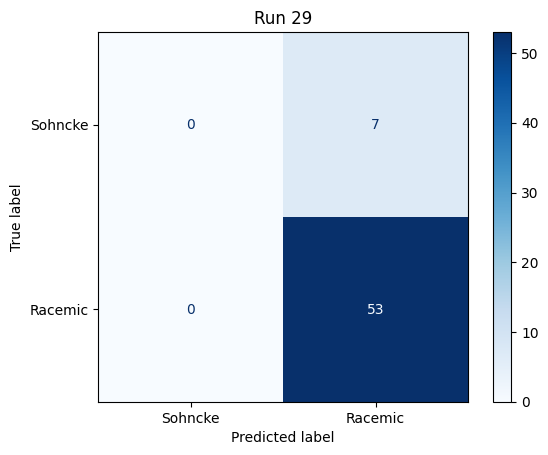

Run 30 completed with accuracy: 91.66666666666666


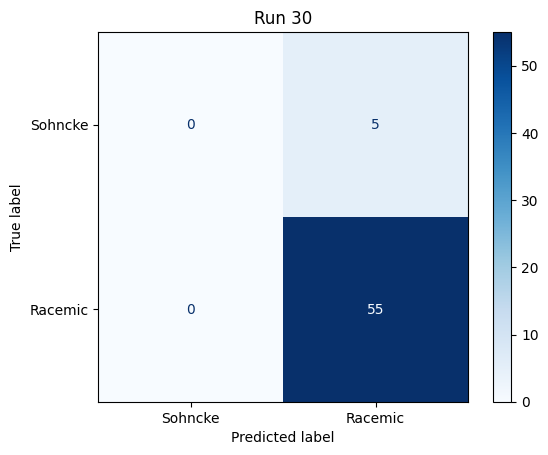

Run 31 completed with accuracy: 88.33333333333333


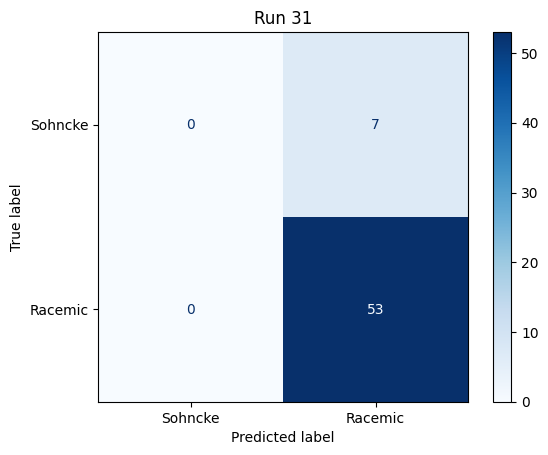

Run 32 completed with accuracy: 83.33333333333334


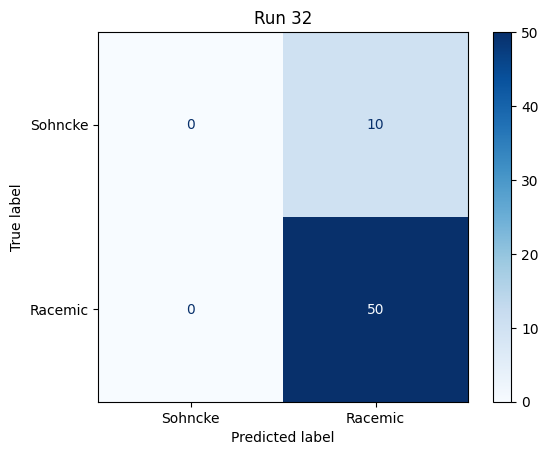

Run 33 completed with accuracy: 85.0


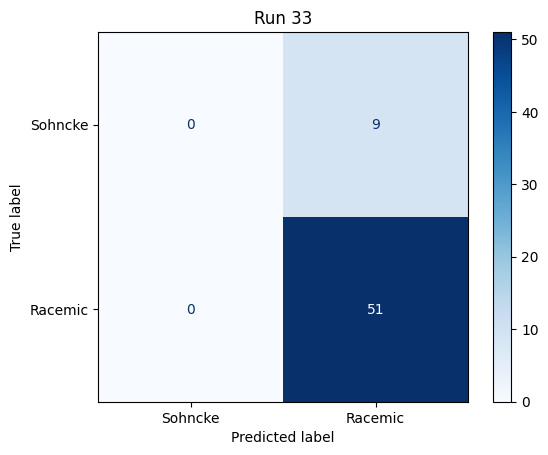

Run 34 completed with accuracy: 91.66666666666666


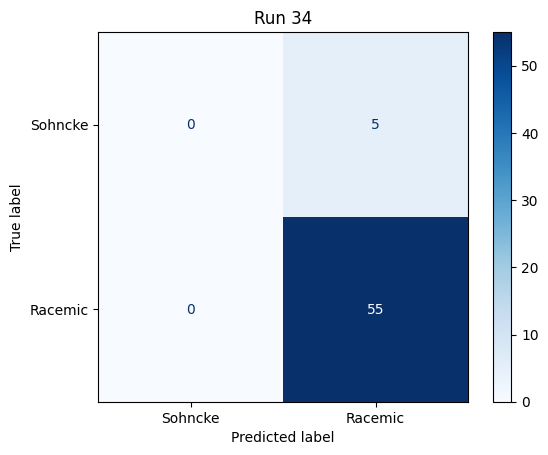

Run 35 completed with accuracy: 91.66666666666666


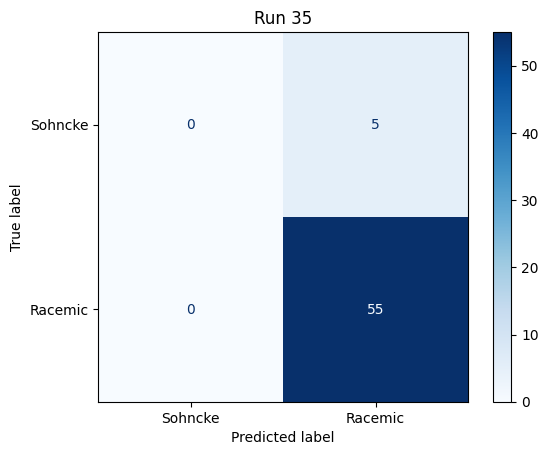

Run 36 completed with accuracy: 75.0


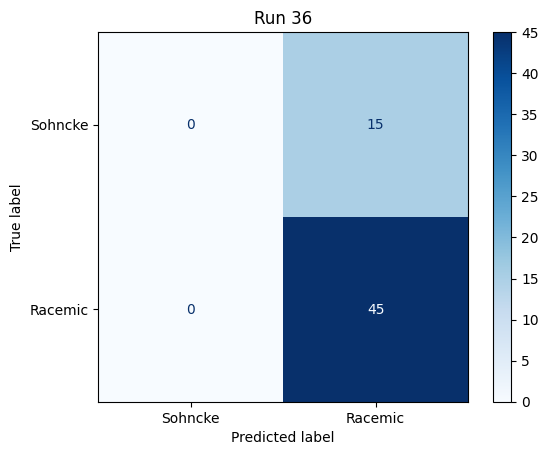

Run 37 completed with accuracy: 76.66666666666667


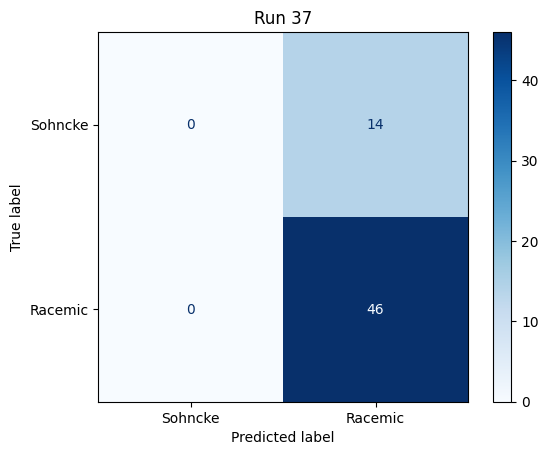

Run 38 completed with accuracy: 85.0


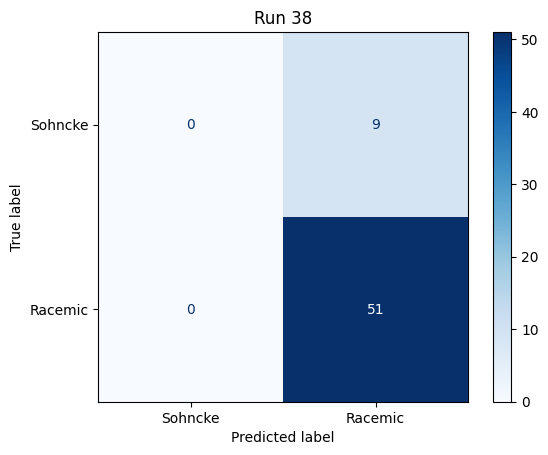

Run 39 completed with accuracy: 76.66666666666667


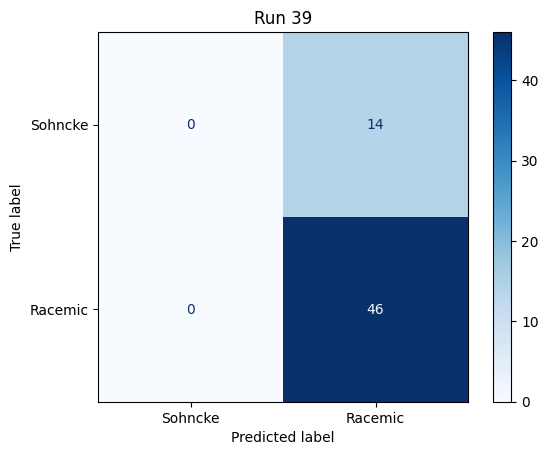

Run 40 completed with accuracy: 83.33333333333334


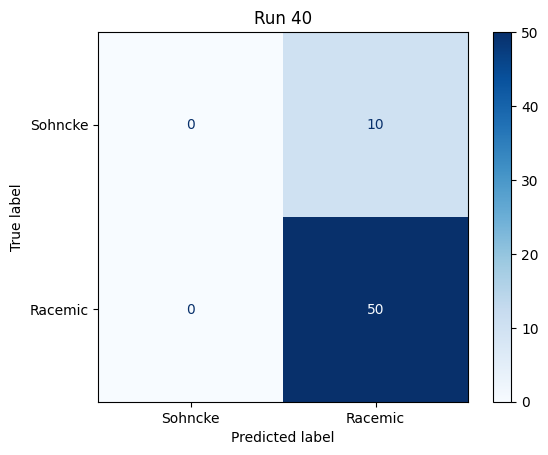

Run 41 completed with accuracy: 88.33333333333333


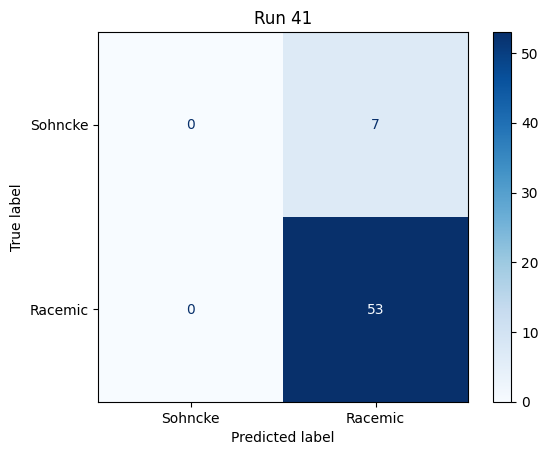

Run 42 completed with accuracy: 83.33333333333334


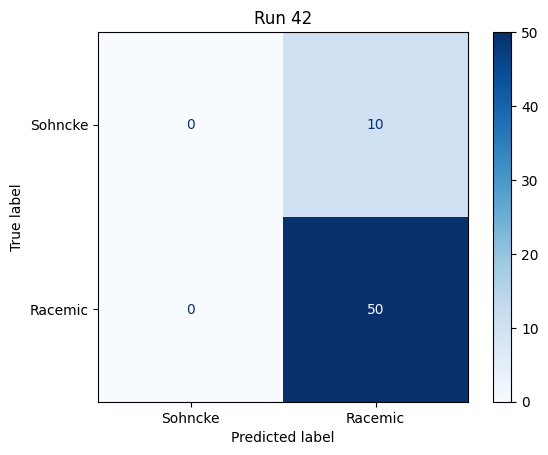

Run 43 completed with accuracy: 85.0


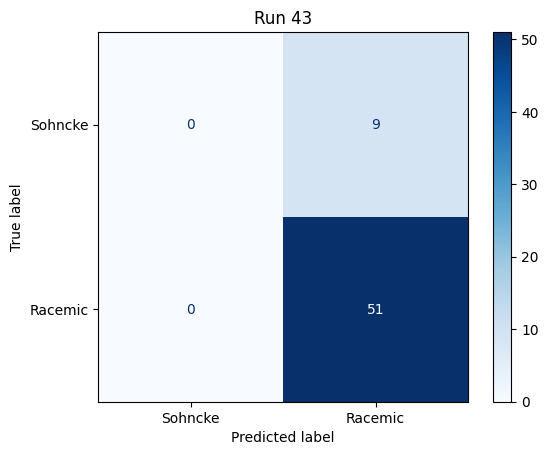

Run 44 completed with accuracy: 86.66666666666667


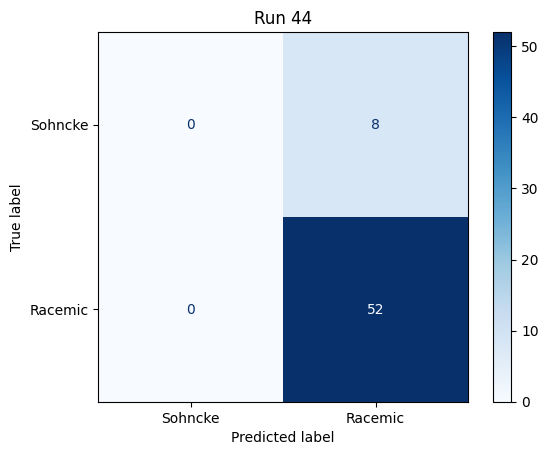

Run 45 completed with accuracy: 86.66666666666667


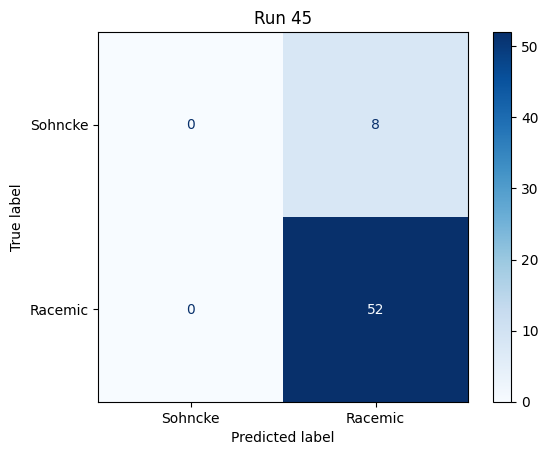

Run 46 completed with accuracy: 78.33333333333333


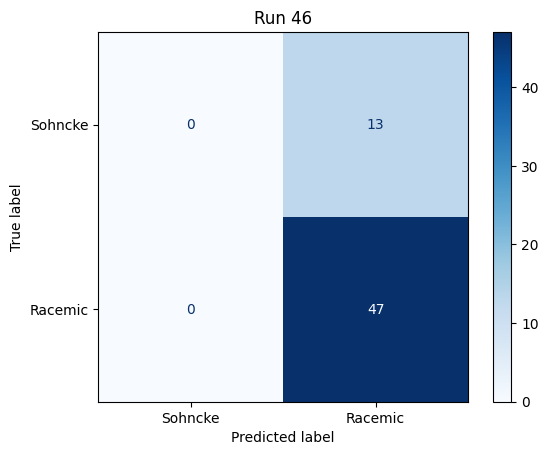

Run 47 completed with accuracy: 85.0


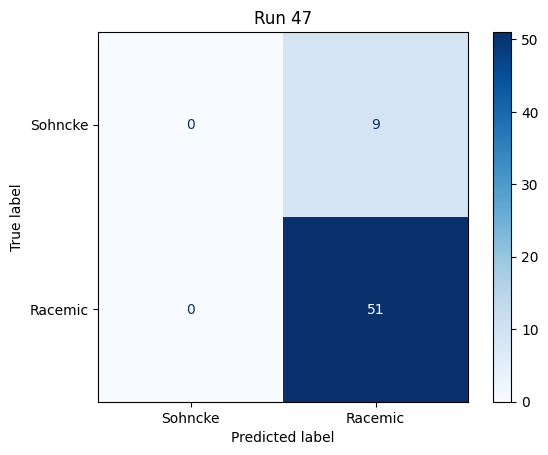

Run 48 completed with accuracy: 95.0


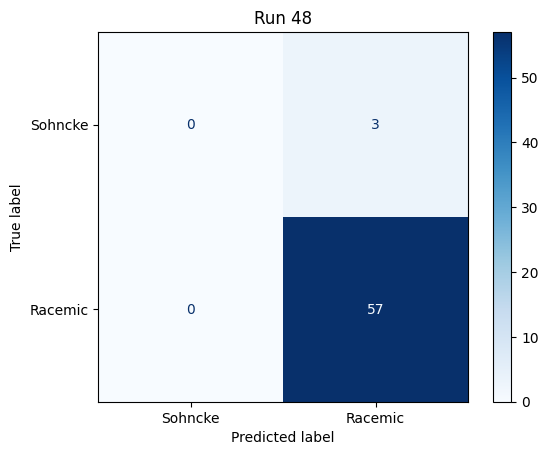

Run 49 completed with accuracy: 86.66666666666667


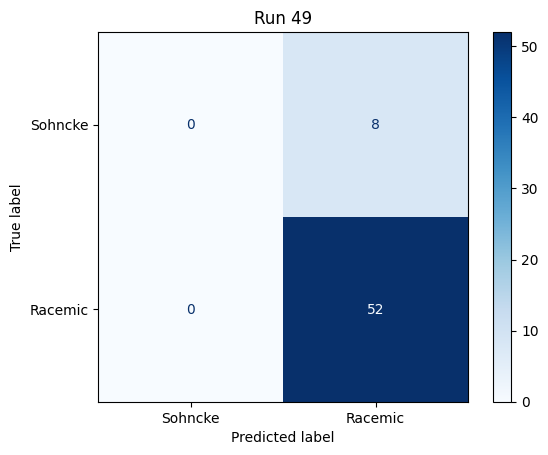

Run 50 completed with accuracy: 83.33333333333334


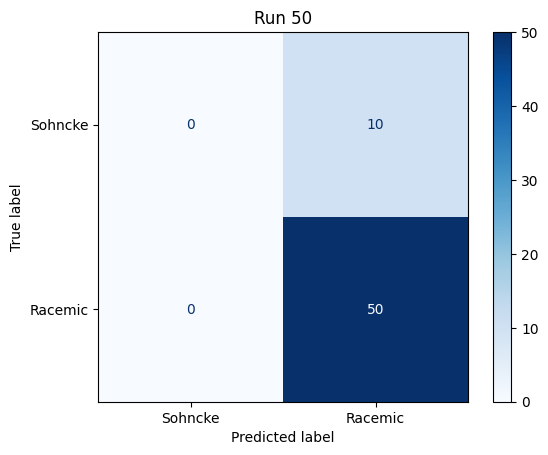

Run 51 completed with accuracy: 86.66666666666667


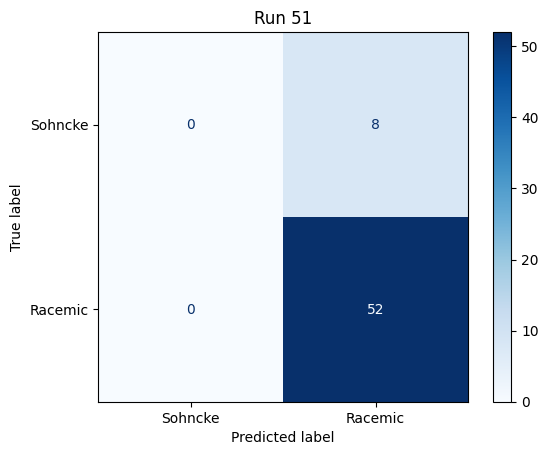

Run 52 completed with accuracy: 88.33333333333333


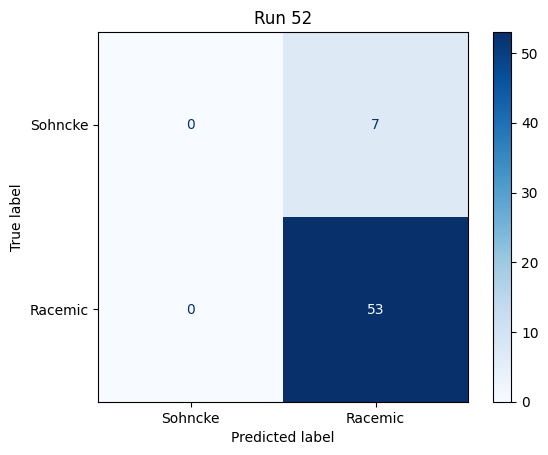

Run 53 completed with accuracy: 81.66666666666667


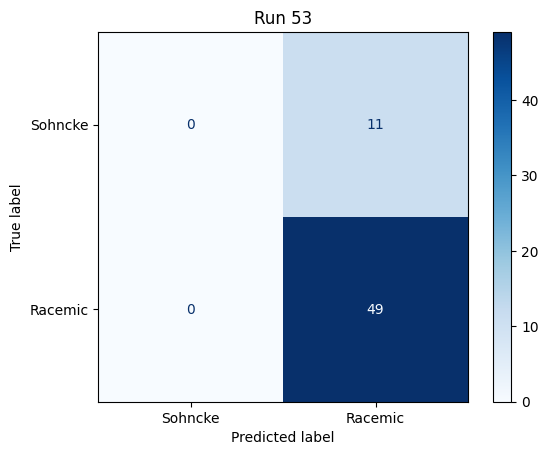

Run 54 completed with accuracy: 90.0


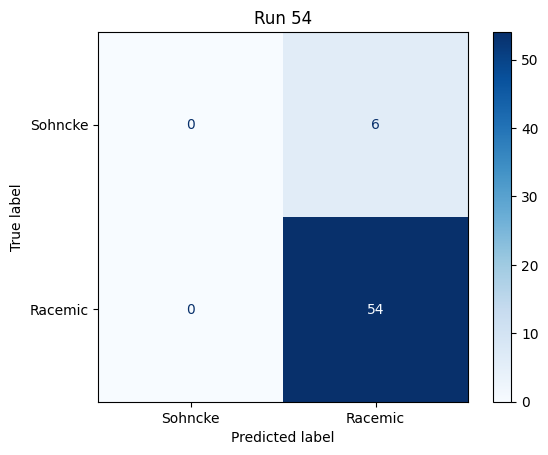

Run 55 completed with accuracy: 73.33333333333333


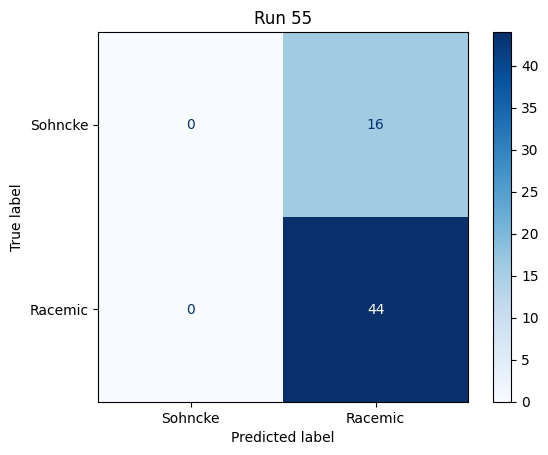

Run 56 completed with accuracy: 81.66666666666667


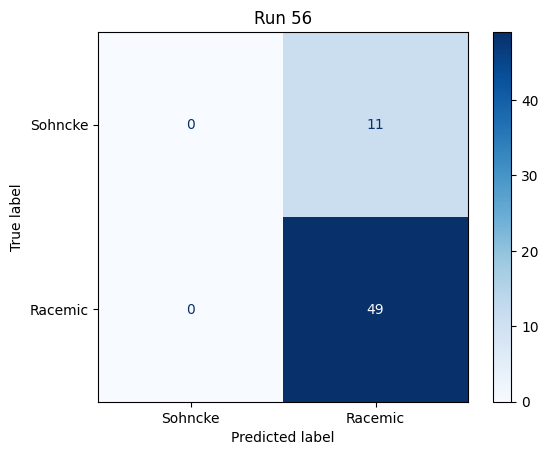

Run 57 completed with accuracy: 81.66666666666667


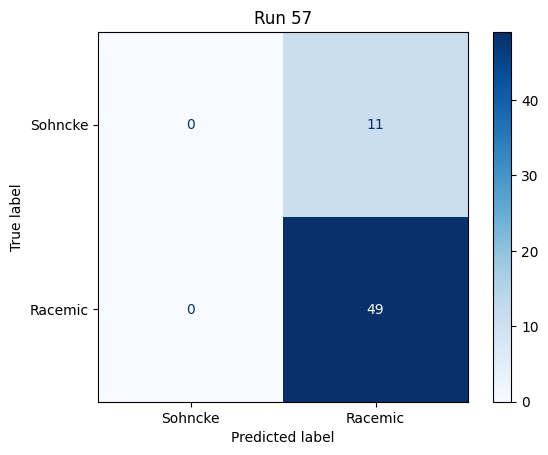

Run 58 completed with accuracy: 83.33333333333334


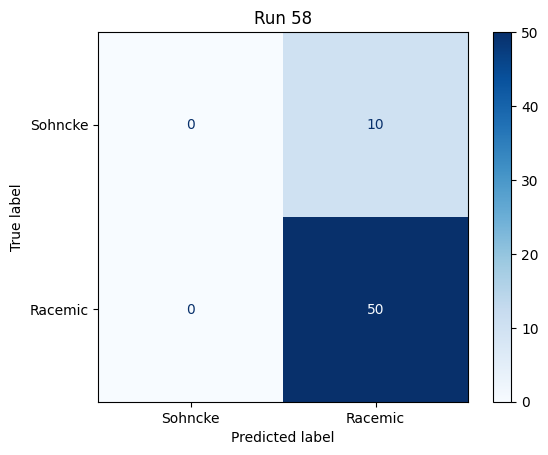

Run 59 completed with accuracy: 85.0


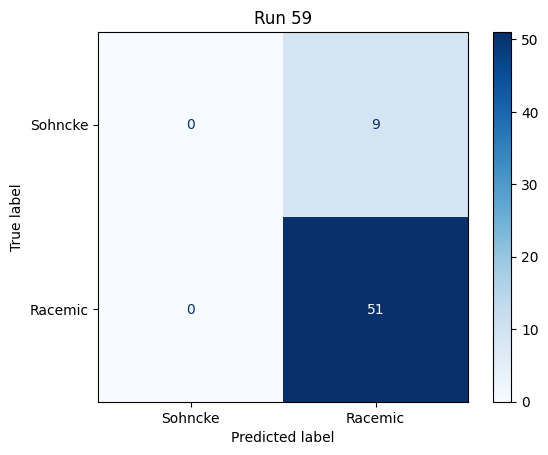

Run 60 completed with accuracy: 80.0


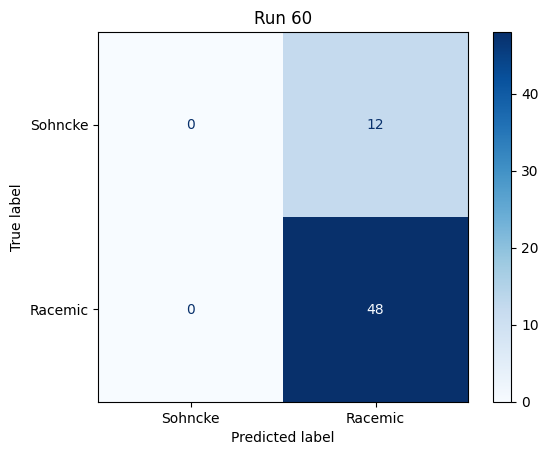

Run 61 completed with accuracy: 81.66666666666667


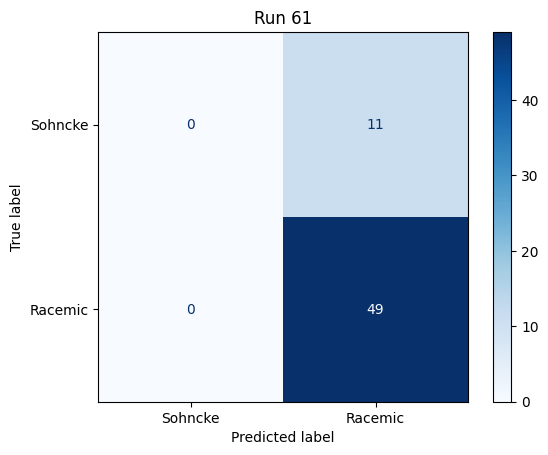

Run 62 completed with accuracy: 83.33333333333334


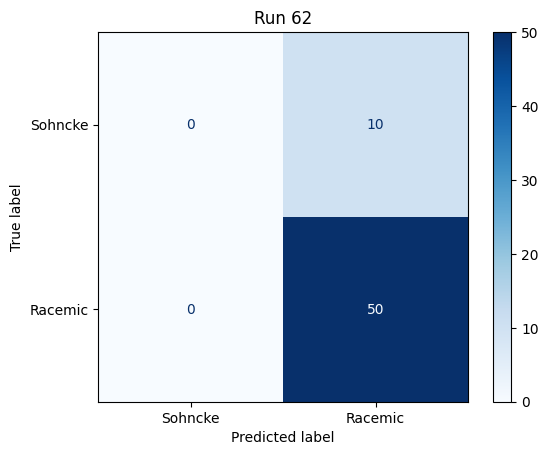

Run 63 completed with accuracy: 85.0


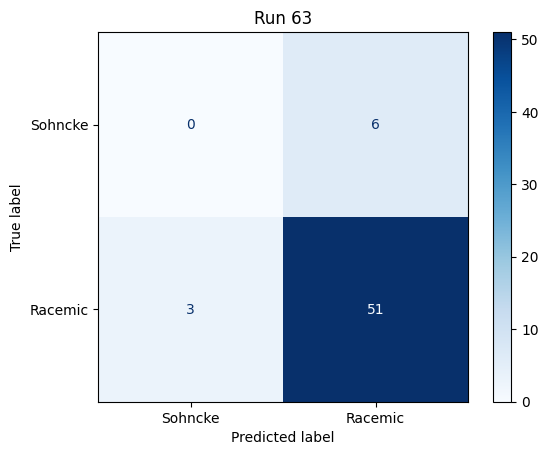

Run 64 completed with accuracy: 81.66666666666667


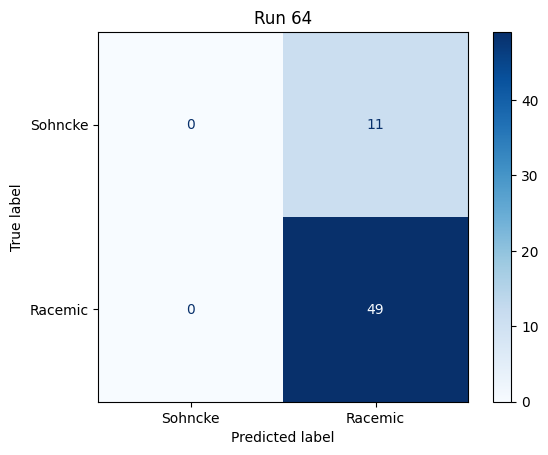

Run 65 completed with accuracy: 83.33333333333334


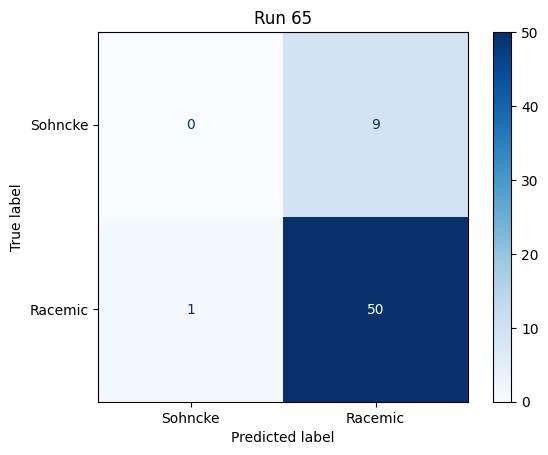

Run 66 completed with accuracy: 88.33333333333333


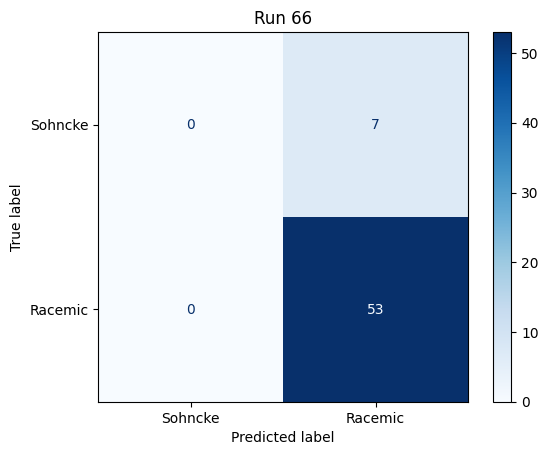

Run 67 completed with accuracy: 81.66666666666667


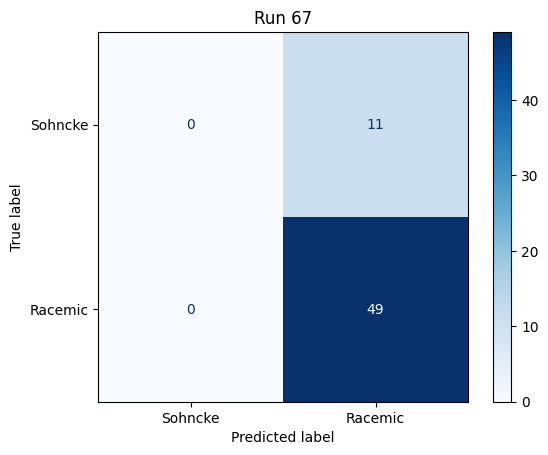

Run 68 completed with accuracy: 78.33333333333333


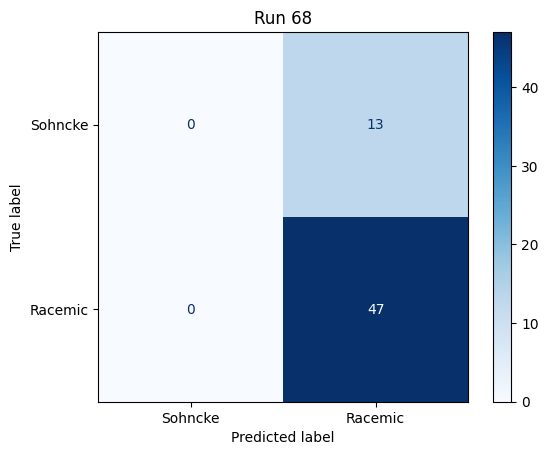

Run 69 completed with accuracy: 85.0


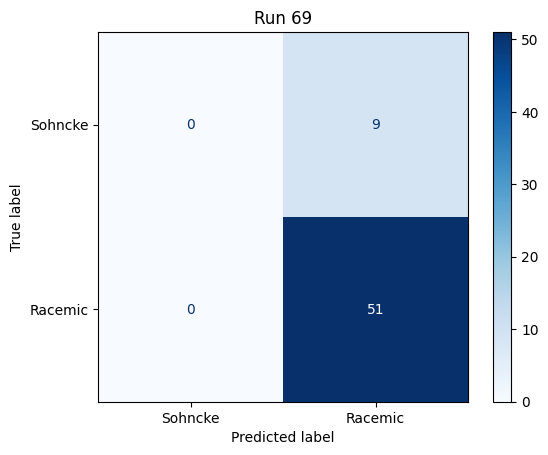

Run 70 completed with accuracy: 93.33333333333333


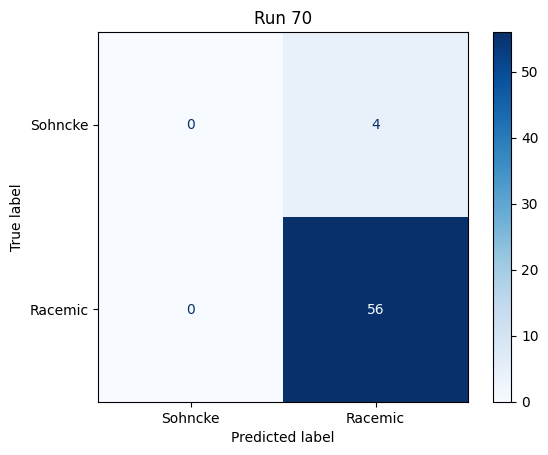

Run 71 completed with accuracy: 88.33333333333333


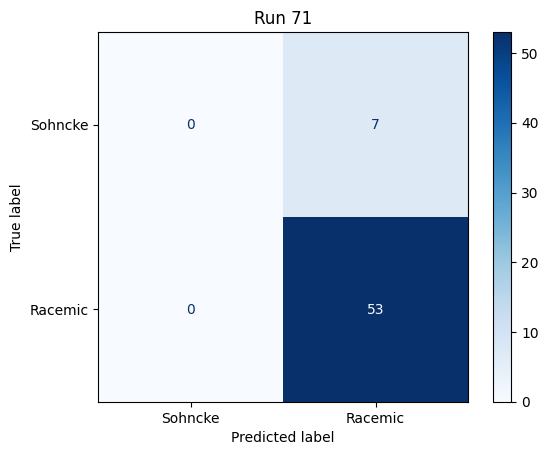

Run 72 completed with accuracy: 85.0


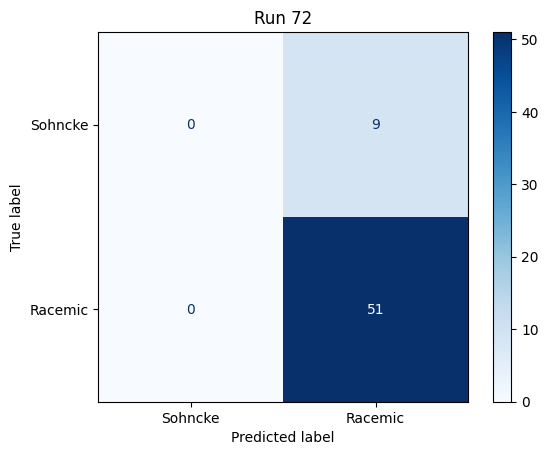

Run 73 completed with accuracy: 86.66666666666667


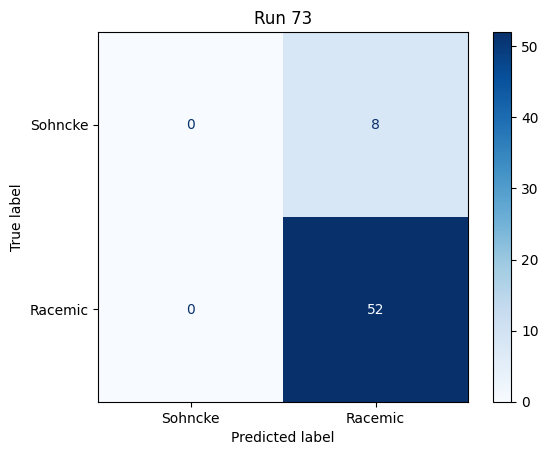

Run 74 completed with accuracy: 81.66666666666667


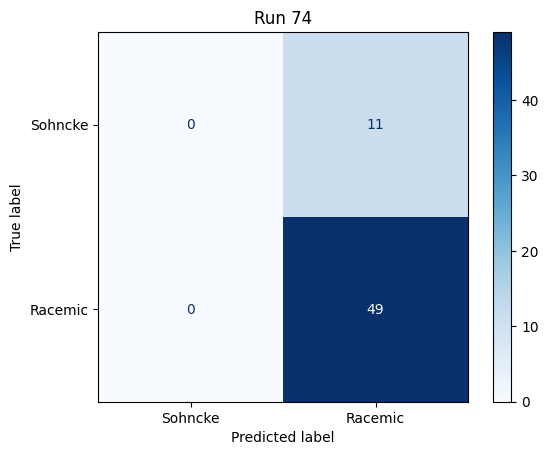

Run 75 completed with accuracy: 90.0


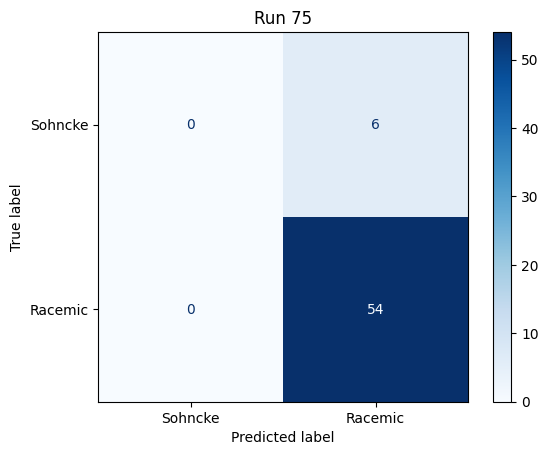

Run 76 completed with accuracy: 85.0


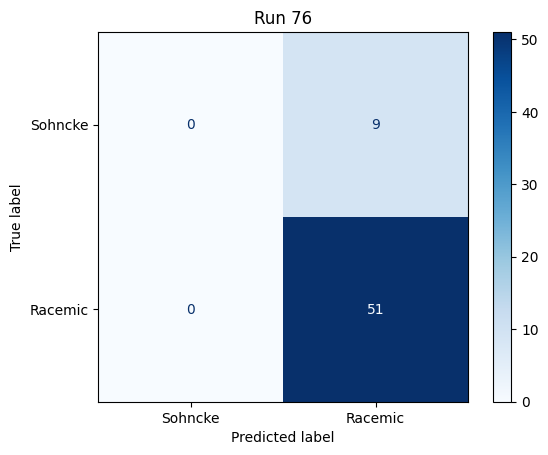

Run 77 completed with accuracy: 81.66666666666667


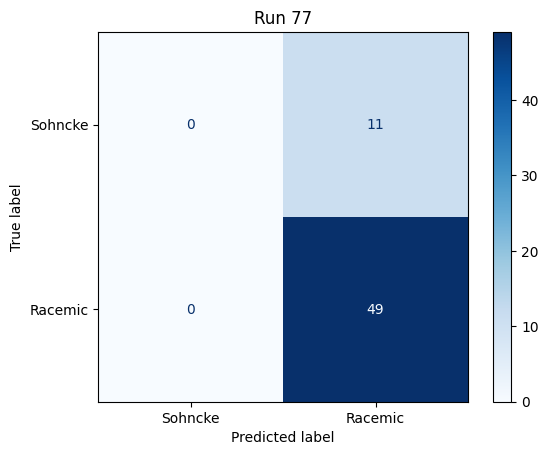

Run 78 completed with accuracy: 86.66666666666667


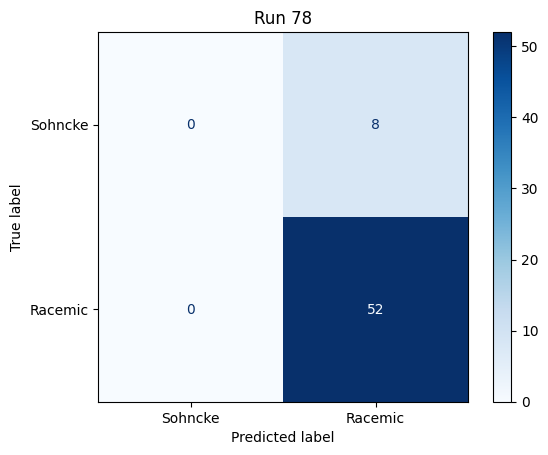

Run 79 completed with accuracy: 88.33333333333333


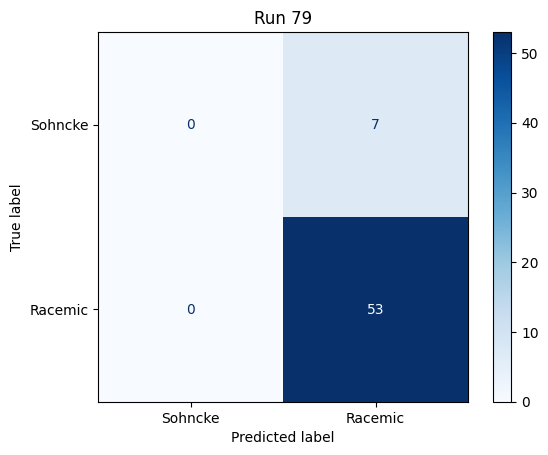

Run 80 completed with accuracy: 83.33333333333334


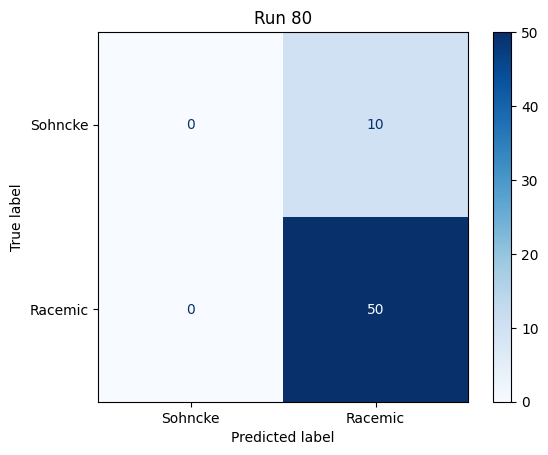

Run 81 completed with accuracy: 81.66666666666667


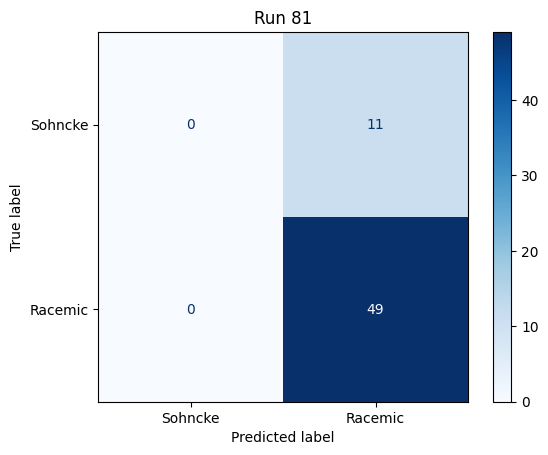

Run 82 completed with accuracy: 83.33333333333334


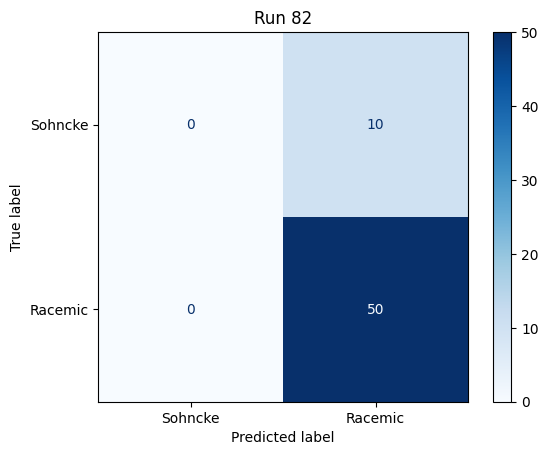

Run 83 completed with accuracy: 88.33333333333333


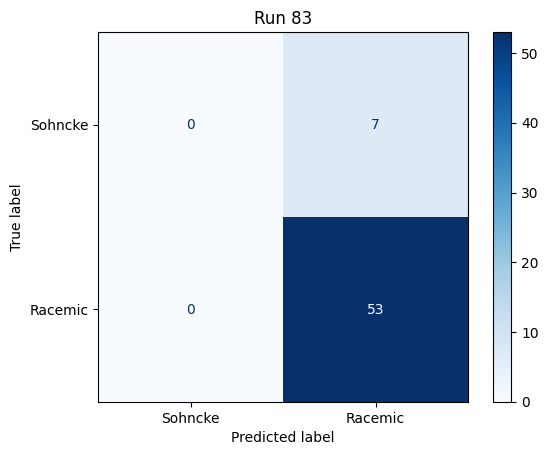

Run 84 completed with accuracy: 85.0


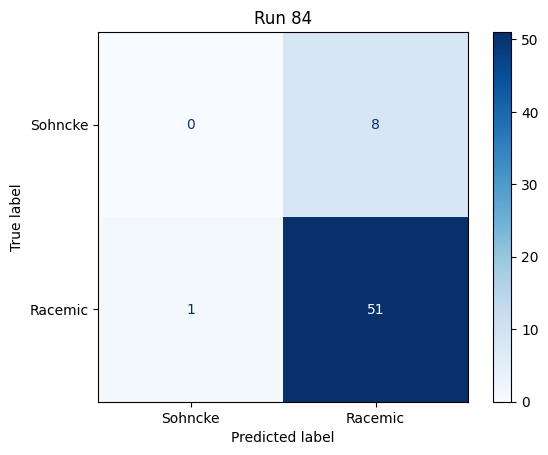

Run 85 completed with accuracy: 86.66666666666667


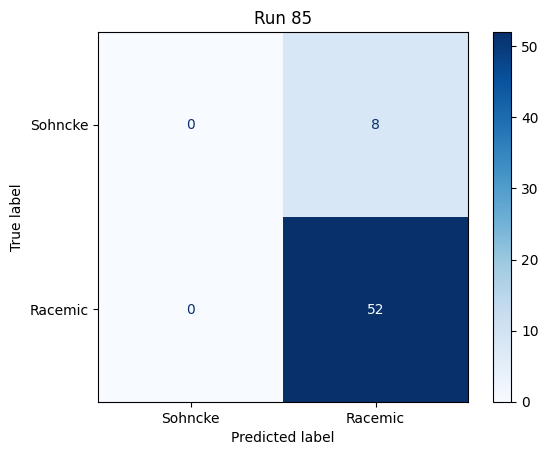

Run 86 completed with accuracy: 91.66666666666666


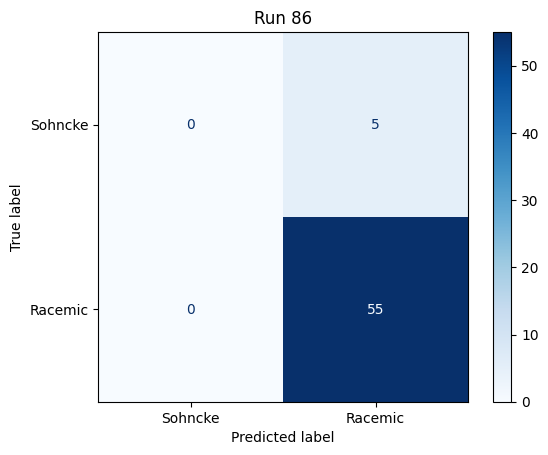

Run 87 completed with accuracy: 86.66666666666667


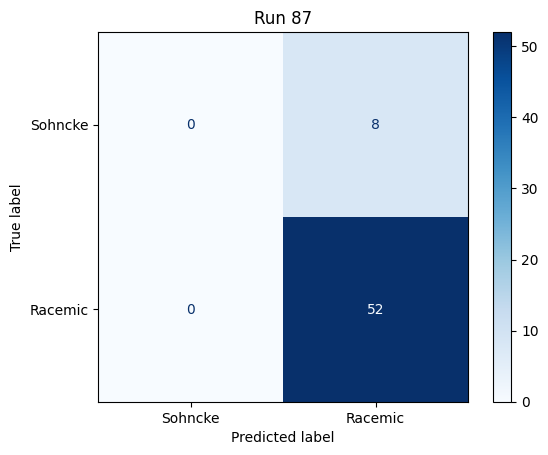

Run 88 completed with accuracy: 88.33333333333333


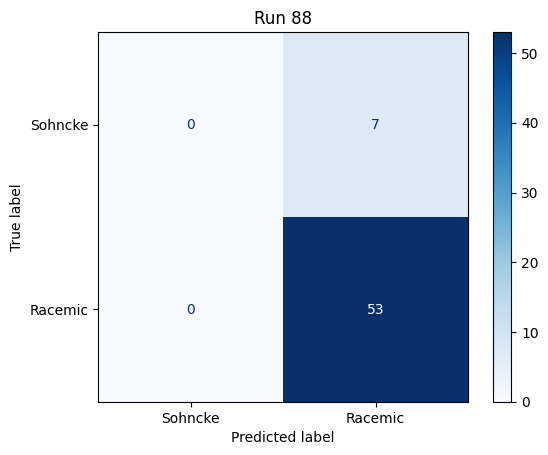

Run 89 completed with accuracy: 88.33333333333333


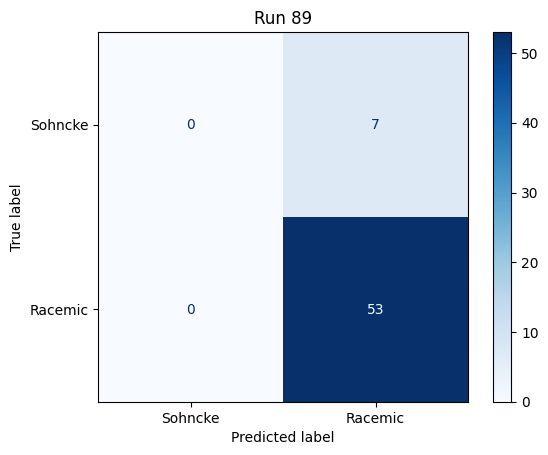

Run 90 completed with accuracy: 85.0


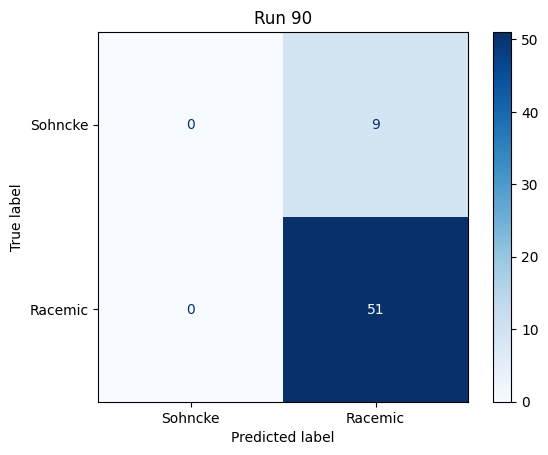

Run 91 completed with accuracy: 85.0


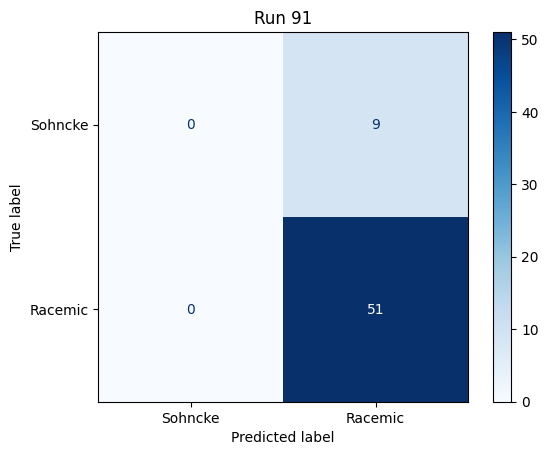

Run 92 completed with accuracy: 80.0


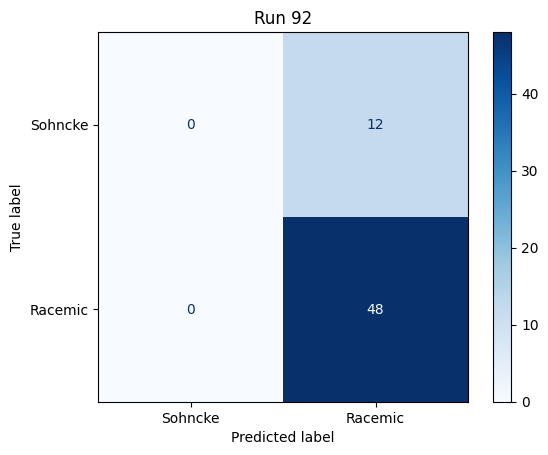

Run 93 completed with accuracy: 86.66666666666667


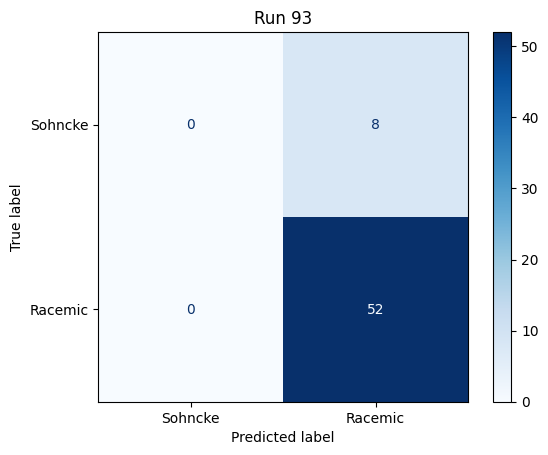

Run 94 completed with accuracy: 73.33333333333333


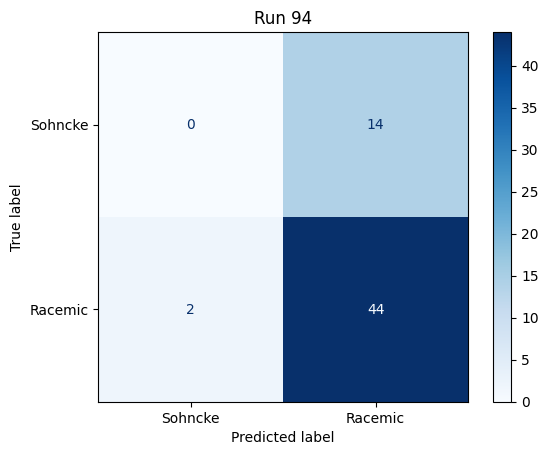

Run 95 completed with accuracy: 83.33333333333334


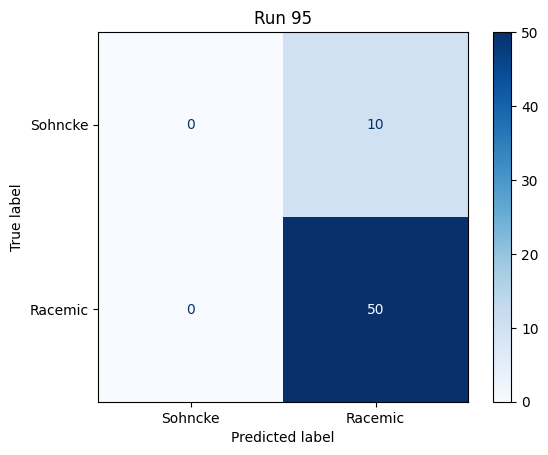

Run 96 completed with accuracy: 88.33333333333333


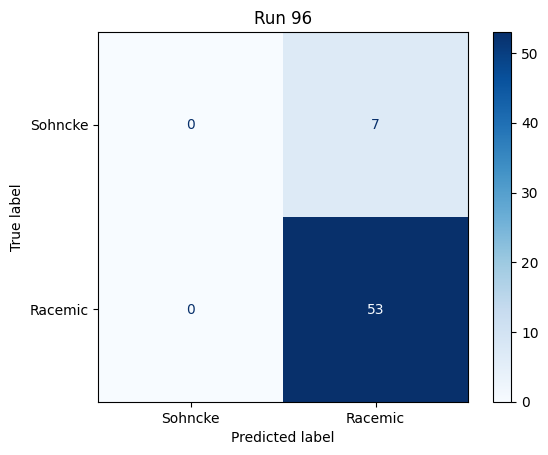

Run 97 completed with accuracy: 81.66666666666667


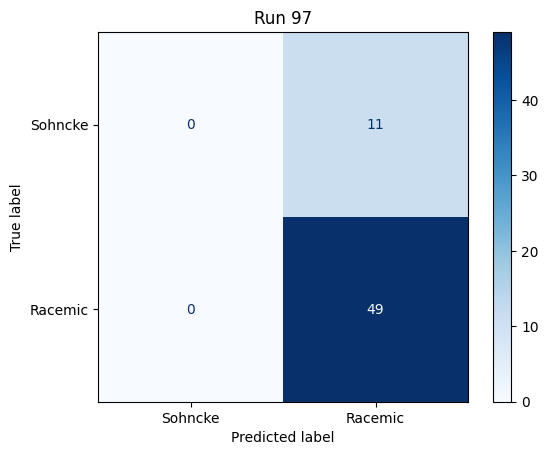

Run 98 completed with accuracy: 86.66666666666667


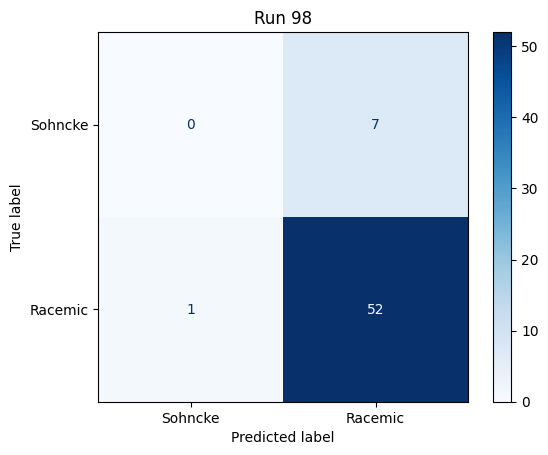

Run 99 completed with accuracy: 83.33333333333334


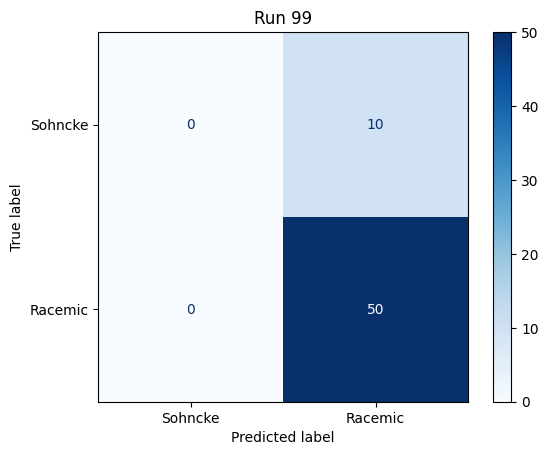

Run 100 completed with accuracy: 85.0


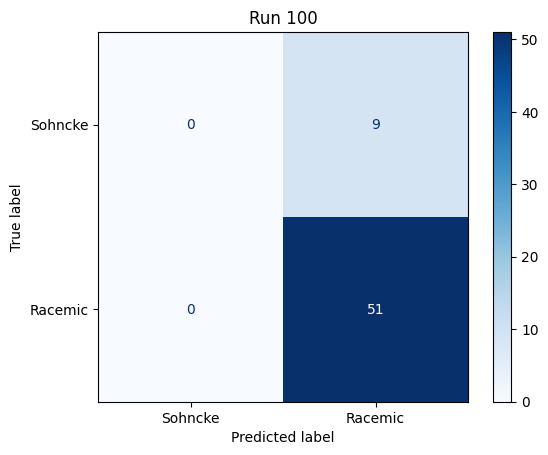

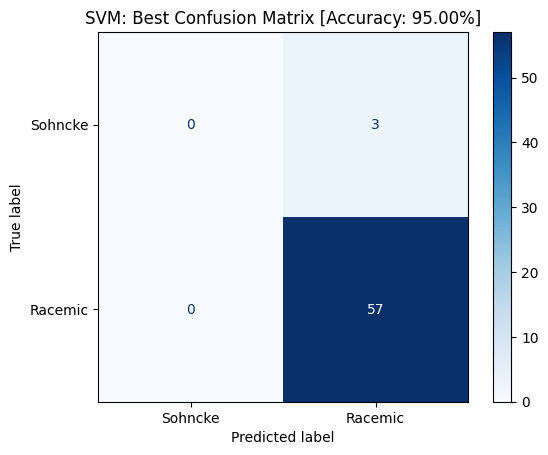

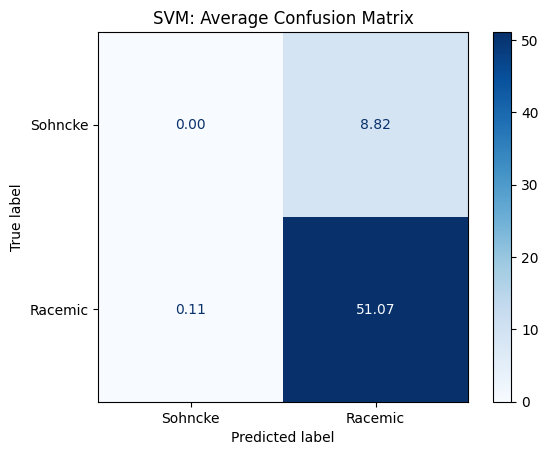

Average Accuracy over 100 runs: 85.12%


In [4]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Load the data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)

# Clean the data
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

# Convert to numpy arrays
X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables to store results
accuracies = []
confusion_matrices = []

# Run the model 100 times
for _ in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    # Perform grid search to find optimal parameters
    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )
    optimal_params.fit(X_train, y_train)
    
    # Train the classifier with the best parameters
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)
    
    # Make predictions
    y_predict = classifier.predict(X_test)
    
    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)

    print(f'Run {_+1} completed with accuracy: {accuracy}')
    ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, display_labels=["Sohncke", "Racemic"],cmap=plt.cm.Blues,values_format='d')
    plt.title(f'Run {_+1}')
    plt.show()
    plt.close()

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best confusion matrix (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'SVM: Best Confusion Matrix [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('SVM: Average Confusion Matrix')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")

{'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 63.33333333333333


Text(0.5, 1.0, 'Generation 2.1 Model Confusion Matrix')

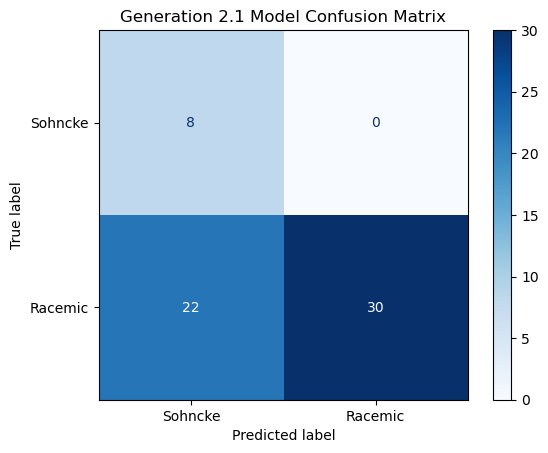

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import joblib

# Load the saved model
model = joblib.load(r'best_svc_model_gen_2_1.pkl')

list = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list)
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

X = np.asarray(feature_df)

y = np.asarray(df_cleaned['Target'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

param_grid = [
        {'C': [0.5, 1, 10, 100],
        'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
        'kernel': ['rbf', 'linear', 'poly']}
    ]

optimal_params = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0
)

optimal_params.fit(X_train, y_train)
print(optimal_params.best_params_)
classifer = svm.SVC(kernel='rbf', gamma='scale', C=0.5)
classifer.fit(X_train, y_train)
y_predict = model.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_predict)*100)

ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Generation 2.1 Model Confusion Matrix')

{'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 73.33333333333333


Text(0.5, 1.0, 'Generation 2.1 Model Confusion Matrix')

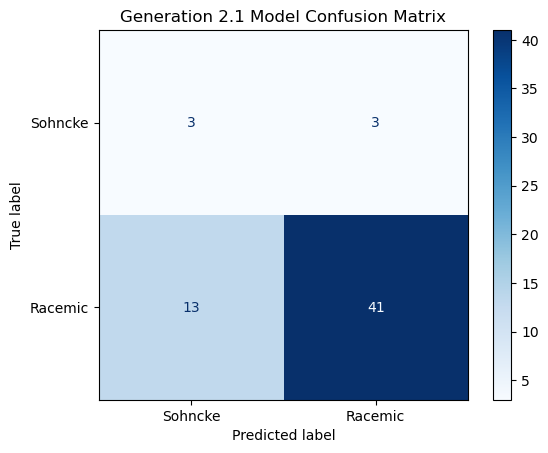

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import joblib

# Load the saved model
model = joblib.load(r'best_log_reg_gen_2_2.pkl')

list = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list)
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

X = np.asarray(feature_df)

y = np.asarray(df_cleaned['Target'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

param_grid = [
        {'C': [0.5, 1, 10, 100],
        'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
        'kernel': ['rbf', 'linear', 'poly']}
    ]

optimal_params = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0
)

optimal_params.fit(X_train, y_train)
print(optimal_params.best_params_)
classifer = svm.SVC(kernel='rbf', gamma='scale', C=0.5)
classifer.fit(X_train, y_train)
y_predict = model.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_predict)*100)

ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Generation 2.1 Model Confusion Matrix')

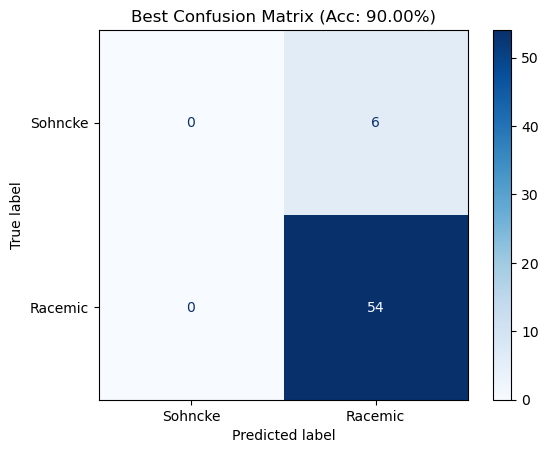

Average accuracy over 100 runs: 84.00%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

# Load the saved model
model = joblib.load(r'best_log_reg_gen_2_2.pkl')

# Load data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Define parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables for tracking best model and accuracies
best_accuracy = 0
best_confusion_matrix = None
accuracies = []

# Run the model 100 times
for _ in range(10):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    # GridSearchCV to find the best parameters
    optimal_params = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy',
        verbose=0
    )
    optimal_params.fit(X_train, y_train)
    
    # Train the model with the best parameters
    classifier = optimal_params.best_estimator_
    classifier.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_predict = classifier.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Update the best model if this one is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = metrics.confusion_matrix(y_test, y_predict)

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Display the best confusion matrix
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(
    cmap=plt.cm.Blues, values_format='d', ax=ax
)
plt.title(f'Best Confusion Matrix (Acc: {best_accuracy:.2f}%)')
plt.show()

# Print the average accuracy
print(f'Average accuracy over 100 runs: {average_accuracy:.2f}%')


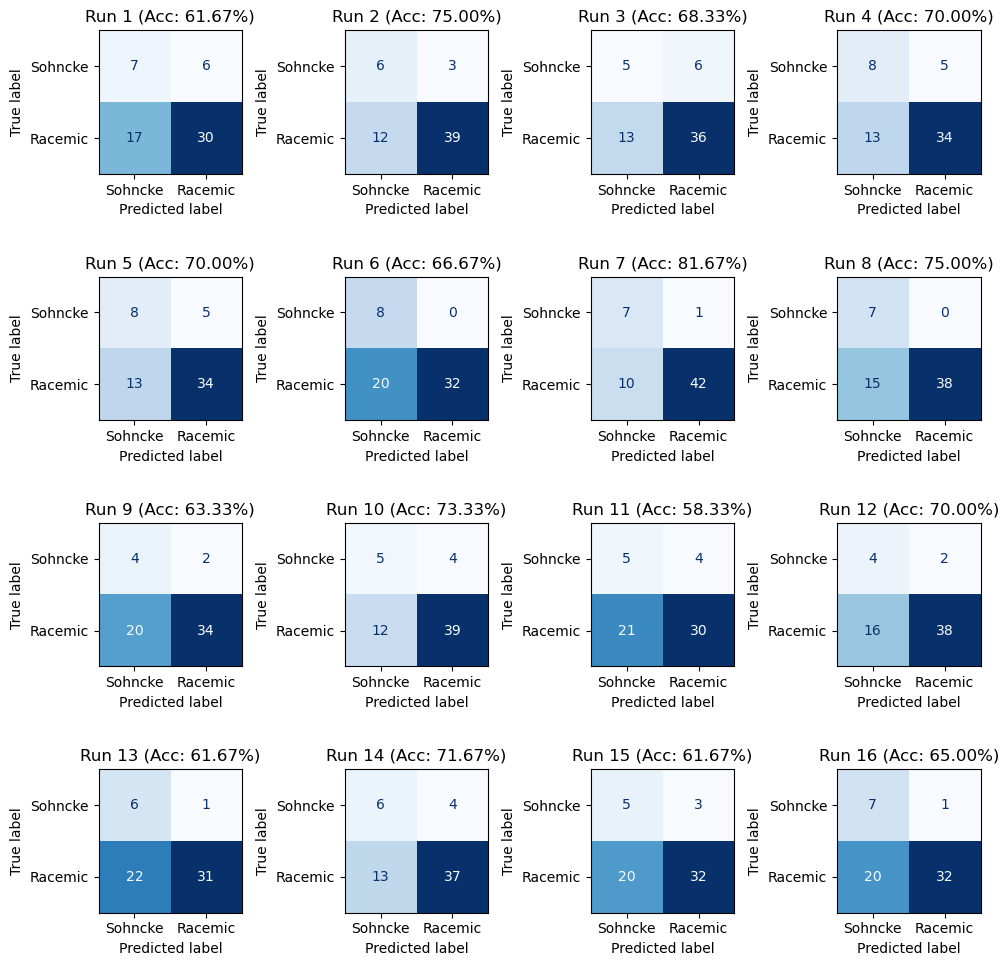

Average accuracy over 100 runs: 68.33%


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import joblib

# Load the saved model
model = joblib.load(r'best_log_reg_gen_2_2.pkl')

# Load data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Define parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables for tracking best model and accuracies
best_accuracy = 0
best_confusion_matrix = None
accuracies = []
confusion_matrices = []

# Run the model 100 times
for run_index in range(16):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_predict = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Get confusion matrix
    confusion_matrix = metrics.confusion_matrix(y_test, y_predict)
    confusion_matrices.append((confusion_matrix, accuracy))
    
    # Update the best model if this one is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_confusion_matrix = confusion_matrix

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Plot all confusion matrices
fig, axes = plt.subplots(4, 4, figsize=(10, 10))  # Adjust the size as needed
axes = axes.flatten()

for i, (conf_matrix, acc) in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Sohncke", "Racemic"])
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f'Run {i+1} (Acc: {acc:.2f}%)')

# Adjust layout
plt.tight_layout()
plt.show()

# Print the average accuracy
print(f'Average accuracy over 100 runs: {average_accuracy:.2f}%')


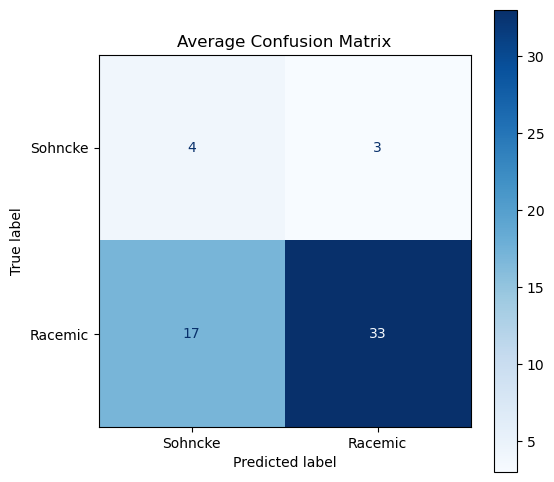

Average accuracy over 100 runs: 64.35%


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import joblib

# Load the saved model
model = joblib.load(r'best_log_reg_gen_2_2.pkl')

# Load data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Define parameter grid for GridSearchCV
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

# Initialize variables for tracking best model, accuracies, and confusion matrices
best_accuracy = 0
best_confusion_matrix = None
accuracies = []
sum_confusion_matrix = np.zeros((2, 2))  # Initialize a zero matrix for summing

# Run the model 100 times
for run_index in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    
    # Predict and calculate accuracy
    y_predict = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Get confusion matrix
    confusion_matrix = metrics.confusion_matrix(y_test, y_predict)
    
    # Sum confusion matrices for average calculation
    sum_confusion_matrix += confusion_matrix

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Calculate the average confusion matrix
average_confusion_matrix = sum_confusion_matrix / 100

# Plot the average confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))  # Define a new figure for the average confusion matrix
disp_avg = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix.astype(int), display_labels=["Sohncke", "Racemic"])
disp_avg.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
ax.set_title('Average Confusion Matrix')

# Display the plot
plt.show()

# Print the average accuracy
print(f'Average accuracy over 100 runs: {average_accuracy:.2f}%')
